# Fixed-Point Quantization Testbed

This notebook evaluates model performance under different fixed-point quantization bit-widths.

**Key Metrics:**
- ROC curves
- AUC (Area Under Curve)
- TPR at FPR = 1e-5

**Quantization formats tested:**
- Float32 (baseline)
- Various fixed-point: Q<I>.<F> where I=integer bits, F=fractional bits

In [28]:
# Imports
import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# Set up paths
sys.path.insert(0, os.path.abspath('..'))

from cascaded_tn.quantization import QuantizationTestbed
from cascaded_tn.training.cascaded_model import CascadedModel, create_trainable_autoencoder
from tn4ml.embeddings import embed, TrigonometricEmbedding, ParticleVectorEmbedding
from tn4ml.eval import get_roc_curve_data
from tn4ml.metrics import TransformedNorm

import quimb.tensor as qtn

# Configure JAX
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_default_matmul_precision', 'float32')

print("✅ Imports successful")

✅ Imports successful


## 1. Load or Create Model

In [ ]:
# Load trained model
model_dir = '../output/Huber_AE_Results_bd8_3/'
model_name = 'final_best_model.pkl'
model_path = model_dir + '/' + model_name
autoencoder = CascadedModel.load(model_path)
print(f"✅ Loaded trained model from {model_path}")
print(f"   Parameters: {autoencoder.nparams():,}")

print(f"✅ Model ready")
print(f"   Architecture: {[op.config.input_dim for op in autoencoder.cascade.operators]} → {autoencoder.cascade.operators[-1].config.output_dim}")
print(f"   Parameters: {autoencoder.nparams():,}")
autoencoder.summary()

[LOADING] Model from ../output/Huber_AE_Results_bd8_3/final_best_model.pkl
  - 4,482 parameters
  - 2 layers
[LOADED] Successfully loaded model
✅ Loaded trained model from ../output/Huber_AE_Results_bd8_3/final_best_model.pkl
   Parameters: 4,482
✅ Model ready
   Architecture: [19, 7] → 3
   Parameters: 4,482

CASCADED MODEL SUMMARY

CASCADE SUMMARY: OpenAutoencoder_19to3
Architecture: 19 → 7 → 3

Layers: 2
  0: Unified↓(19→7, χ=8)
  1: Unified↓(7→3, χ=3) (bottleneck)


Training Configuration:
  Strategy: global
  Optimizer: <function adam at 0x7f85f4b6e8e0>
  Learning rate: 0.01
  Loss function: None
  Training type: 0

Total parameters: 4,482

Parameters by layer:
  Layer 0 (Unified↓(19→7, χ=8)): 4,320 parameters
  Layer 1 (Unified↓(7→3, χ=3)): 162 parameters



## 2. Set Up Embedding and Metric Function

In [ ]:
# Set up embedding (use the same one from training)
embedding = ParticleVectorEmbedding(normalize=False)

# Define target loss (adjust based on your training)
target_loss = 50.0

# Define the anomaly score function)
def InputsToScore(model, data):
    """Anomaly score based on deviation from target norm."""
    x = TransformedNorm(model, data)
    return jax.lax.abs(x - target_loss)

@jax.jit
def ComputeScore(data, targets, *params):
    """Compute the anomaly score."""
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    tn_i = embed(data, embedding)
    compressed = temp_model.cascade.apply(tn_i)
    
    return InputsToScore(compressed, tn_i)

# Vectorize for batch processing
score_term = jax.jit(jax.vmap(ComputeScore, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

print("✅ Metric function ready")

✅ Metric function ready


## 3. Create Toy Data Loaders

For demonstration, we create synthetic data. Replace with your real data loaders.

In [ ]:
# Schedule data loading
import utils.dataloader as d
inputPath = "/lus/eagle/projects/ATLAS_workflow_ALCF/sagar/QiML/"
background_loader = d.load_data(inputPath + "background_for_training.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True)
signal_loaders = {
    'A to 4l': d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'LQ': d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'H to tau nu': d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'H to tau tau': d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
}

## 4. Initialize Testbed

In [33]:
# Create testbed
testbed = QuantizationTestbed(model=autoencoder, embedding=embedding)
print("✅ Testbed initialized")

✅ Testbed initialized


## 5. Define Quantization Configurations to Test

In [34]:
# Define quantization configurations to test
# Format: (n_word, n_frac) where n_word = total bits, n_frac = fractional bits
# Integer bits = n_word - n_frac - 1 (for signed)

quantization_configs = [
    # (total_bits, frac_bits, name)
    (18, 12, 'Q5.12 (18-bit)'),   # 1 sign + 5 int + 12 frac
    (16, 10, 'Q5.10 (16-bit)'),   # 1 sign + 5 int + 10 frac
    (16, 8,  'Q7.8 (16-bit)'),    # 1 sign + 7 int + 8 frac
    (12, 8,  'Q3.8 (12-bit)'),    # 1 sign + 3 int + 8 frac
    (8,  4,  'Q3.4 (8-bit)'),     # 1 sign + 3 int + 4 frac
]

print("Quantization configurations to test:")
for n_word, n_frac, name in quantization_configs:
    n_int = n_word - n_frac - 1
    range_val = 2**n_int
    resolution = 2**(-n_frac)
    print(f"  {name}: range=[-{range_val}, {range_val}), resolution={resolution:.8f}")

Quantization configurations to test:
  Q5.12 (18-bit): range=[-32, 32), resolution=0.00024414
  Q5.10 (16-bit): range=[-32, 32), resolution=0.00097656
  Q7.8 (16-bit): range=[-128, 128), resolution=0.00390625
  Q3.8 (12-bit): range=[-8, 8), resolution=0.00390625
  Q3.4 (8-bit): range=[-8, 8), resolution=0.06250000


## 6. Evaluate Float32 Baseline

In [35]:
print("\n" + "="*80)
print("EVALUATING FLOAT32 BASELINE")
print("="*80)

# Evaluate background
bkg_float = testbed.evaluate_float(background_loader, score_term, verbose=True)

# Evaluate signals
signals_float = {}
for signal_name, signal_loader in signal_loaders.items():
    signals_float[signal_name] = testbed.evaluate_float(signal_loader, score_term, verbose=True)

print("\n✅ Float32 baseline complete")
print(f"   Background: {len(bkg_float)} samples")
print(f"   Signals: {[f'{k} ({len(v)} samples)' for k, v in signals_float.items()]}")


EVALUATING FLOAT32 BASELINE


Evaluating (float32): 100%|██████████| 70/70 [00:03<00:00, 23.11it/s]


✅ Float32 baseline complete
   Background: 4000000 samples
   Signals: ['A to 4l (55969 samples)', 'LQ (340544 samples)', 'H to tau nu (760272 samples)', 'H to tau tau (691283 samples)']


## 7. Run Quantization Sweep

In [36]:
# Store results
all_results = {
    'float32': {
        'background': bkg_float,
        'signals': signals_float,
    }
}

# Test each quantization config
for n_word, n_frac, name in quantization_configs:
    print("\n" + "="*80)
    print(f"TESTING: {name}")
    print("="*80)
    
    # Quantize model
    testbed.quantize(n_word=n_word, n_frac=n_frac, signed=True)
    
    # Evaluate background
    bkg_quant = testbed.evaluate_quantized(background_loader, score_term, verbose=True)
    
    # Evaluate signals
    signals_quant = {}
    for signal_name, signal_loader in signal_loaders.items():
        signals_quant[signal_name] = testbed.evaluate_quantized(signal_loader, score_term, verbose=True)
    
    # Store results
    all_results[name] = {
        'background': bkg_quant,
        'signals': signals_quant,
        'config': testbed.config,
        'stats': testbed.stats,
    }
    
    print(f"\n✅ {name} complete")

print("\n" + "="*80)
print("ALL EVALUATIONS COMPLETE")
print("="*80)


TESTING: Q5.12 (18-bit)

[QUANTIZATION] Quantizing model to 18 bits (5 integer, 12 fractional)
  Config: Q5.12

QUANTIZATION STATISTICS: Q5.12
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-32.000000, 31.999756]
Resolution: 0.00024414

Per-tensor statistics:


Evaluating (Q5.12):   0%|          | 0/400 [00:00<?, ?it/s]

Evaluating (Q5.12): 100%|██████████| 70/70 [00:25<00:00,  2.77it/s]



✅ Q5.12 (18-bit) complete

TESTING: Q5.10 (16-bit)

[QUANTIZATION] Quantizing model to 16 bits (5 integer, 10 fractional)
  Config: Q5.10

QUANTIZATION STATISTICS: Q5.10
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-32.000000, 31.999023]
Resolution: 0.00097656

Per-tensor statistics:


Evaluating (Q5.10): 100%|██████████| 70/70 [00:25<00:00,  2.78it/s]


...


✅ Q7.8 (16-bit) complete

TESTING: Q3.8 (12-bit)

[QUANTIZATION] Quantizing model to 12 bits (3 integer, 8 fractional)
  Config: Q3.8

QUANTIZATION STATISTICS: Q3.8
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-8.000000, 7.996094]
Resolution: 0.00390625

Per-tensor statistics:


Evaluating (Q3.8): 100%|██████████| 70/70 [00:25<00:00,  2.77it/s]



✅ Q3.8 (12-bit) complete

TESTING: Q3.4 (8-bit)

[QUANTIZATION] Quantizing model to 8 bits (3 integer, 4 fractional)
  Config: Q3.4

QUANTIZATION STATISTICS: Q3.4
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-8.000000, 7.937500]
Resolution: 0.06250000

Per-tensor statistics:


Evaluating (Q3.4): 100%|██████████| 70/70 [00:25<00:00,  2.75it/s]


✅ Q3.4 (8-bit) complete

ALL EVALUATIONS COMPLETE


## 8. Compute Performance Metrics

Calculate AUC and TPR @ FPR=1e-5 for each configuration.

In [ ]:
def get_tpr_at_fpr(fpr_array, tpr_array, target_fpr=1e-5):
    """Get TPR at specific FPR value."""
    idx = np.searchsorted(fpr_array, target_fpr, side='right')
    if idx >= len(tpr_array):
        idx = -1
    return tpr_array[idx]

# Compute metrics for all configs and signals
metrics_table = []

for config_name, results in all_results.items():
    bkg = results['background']
    
    for signal_name, sig in results['signals'].items():
        # Compute ROC
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        tpr_at_1e5 = get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5)
        
        metrics_table.append({
            'Config': config_name,
            'Signal': signal_name,
            'AUC': auc_val,
            'TPR@FPR=1e-5': tpr_at_1e5,
        })

# Create DataFrame
df_metrics = pd.DataFrame(metrics_table)

# Pivot for easier comparison
df_auc = df_metrics.pivot(index='Signal', columns='Config', values='AUC')
df_tpr = df_metrics.pivot(index='Signal', columns='Config', values='TPR@FPR=1e-5')

print("\n" + "="*80)
print("AUC COMPARISON")
print("="*80)
print(df_auc.to_string())

print("\n" + "="*80)
print("TPR @ FPR=1e-5 COMPARISON")
print("="*80)
print(df_tpr.to_string())

# Calculate degradation relative to float32
print("\n" + "="*80)
print("AUC DEGRADATION (vs Float32)")
print("="*80)
df_auc_deg = df_auc.subtract(df_auc['float32'], axis=0)
print(df_auc_deg.to_string())

print("\n" + "="*80)
print("TPR DEGRADATION (vs Float32)")
print("="*80)
df_tpr_deg = df_tpr.subtract(df_tpr['float32'], axis=0)
print(df_tpr_deg.to_string())


AUC COMPARISON
Config        Q3.4 (8-bit)  Q3.8 (12-bit)  Q5.10 (16-bit)  Q5.12 (18-bit)  Q7.8 (16-bit)   float32
Signal                                                                                            
A to 4l           0.499737       0.510312        0.519281        0.659844       0.510312  0.890695
H to tau nu       0.471311       0.488587        0.513940        0.564903       0.488587  0.824161
H to tau tau      0.459811       0.482589        0.498029        0.534005       0.482589  0.727152
LQ                0.453489       0.458008        0.450827        0.502908       0.458008  0.790089

TPR @ FPR=1e-5 COMPARISON
Config        Q3.4 (8-bit)  Q3.8 (12-bit)  Q5.10 (16-bit)  Q5.12 (18-bit)  Q7.8 (16-bit)   float32
Signal                                                                                            
A to 4l           0.011882       0.009452        0.010845        0.011971       0.009452  0.012364
H to tau nu       0.000602       0.001018        0.001098        0

## 9. Plot Score Distributions

In [ ]:
output_dir = model_dir+'/quantization_results'
os.makedirs(output_dir, exist_ok=True)

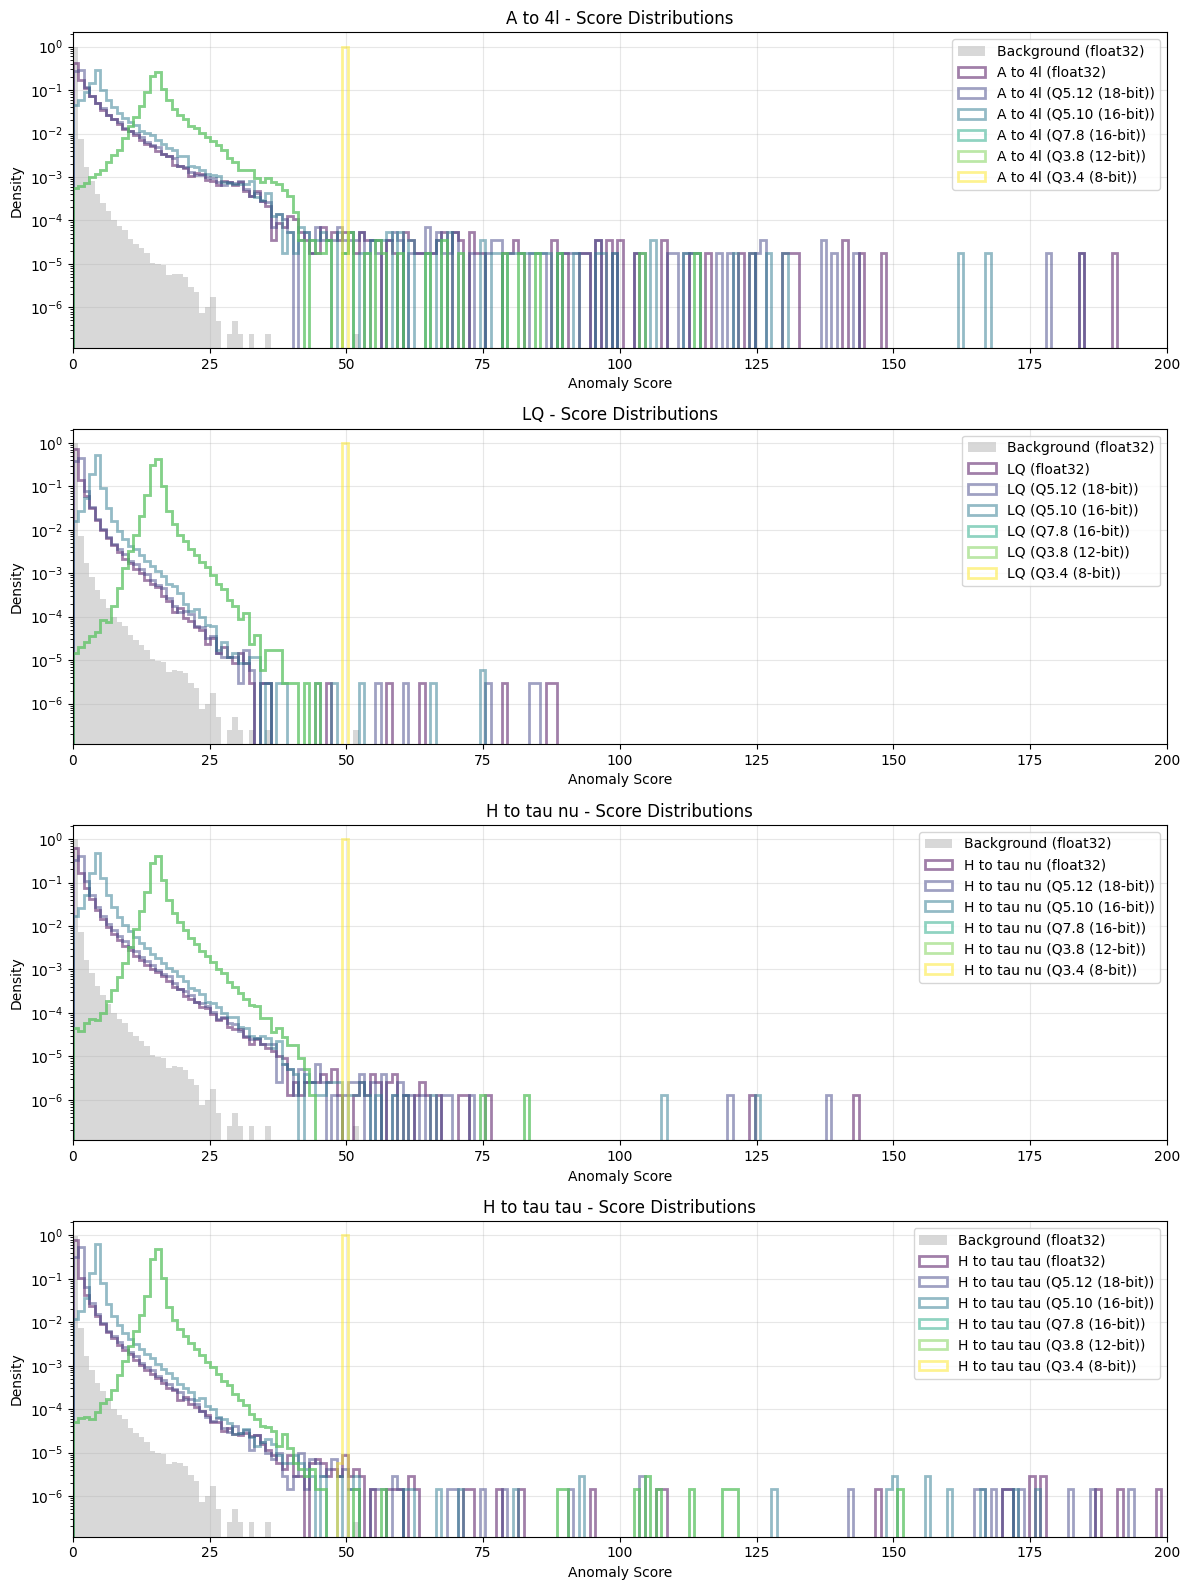

In [57]:
# Plot distributions for each signal
n_signals = len(signal_loaders)
n_configs = len(all_results)

fig, axes = plt.subplots(n_signals, 1, figsize=(12, 4*n_signals))
if n_signals == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_configs))
bins = np.linspace(0, 200, 200)

for sig_idx, signal_name in enumerate(signal_loaders.keys()):
    ax = axes[sig_idx]
    
    # Plot background (same for all)
    bkg_scores = all_results['float32']['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background (float32)', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals for each config
    for config_idx, (config_name, results) in enumerate(all_results.items()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name} ({config_name})',
                density=True, histtype='step', linewidth=2, color=colors[config_idx])
    
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{signal_name} - Score Distributions')
    ax.legend(loc='best')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([0,200])

plt.tight_layout()
plt.savefig(output_dir+"/anomaly_score_distributions_bysignal.png")
plt.show()

0 0
Optimal target for float32: 0.12 (vs original 50.0)
1 0
Optimal target for Q5.12 (18-bit): 1.14 (vs original 50.0)
0 1
Optimal target for Q5.10 (16-bit): 4.44 (vs original 50.0)
1 1
Optimal target for Q7.8 (16-bit): 15.26 (vs original 50.0)
0 2
Optimal target for Q3.8 (12-bit): 15.26 (vs original 50.0)
1 2
Optimal target for Q3.4 (8-bit): 49.95 (vs original 50.0)


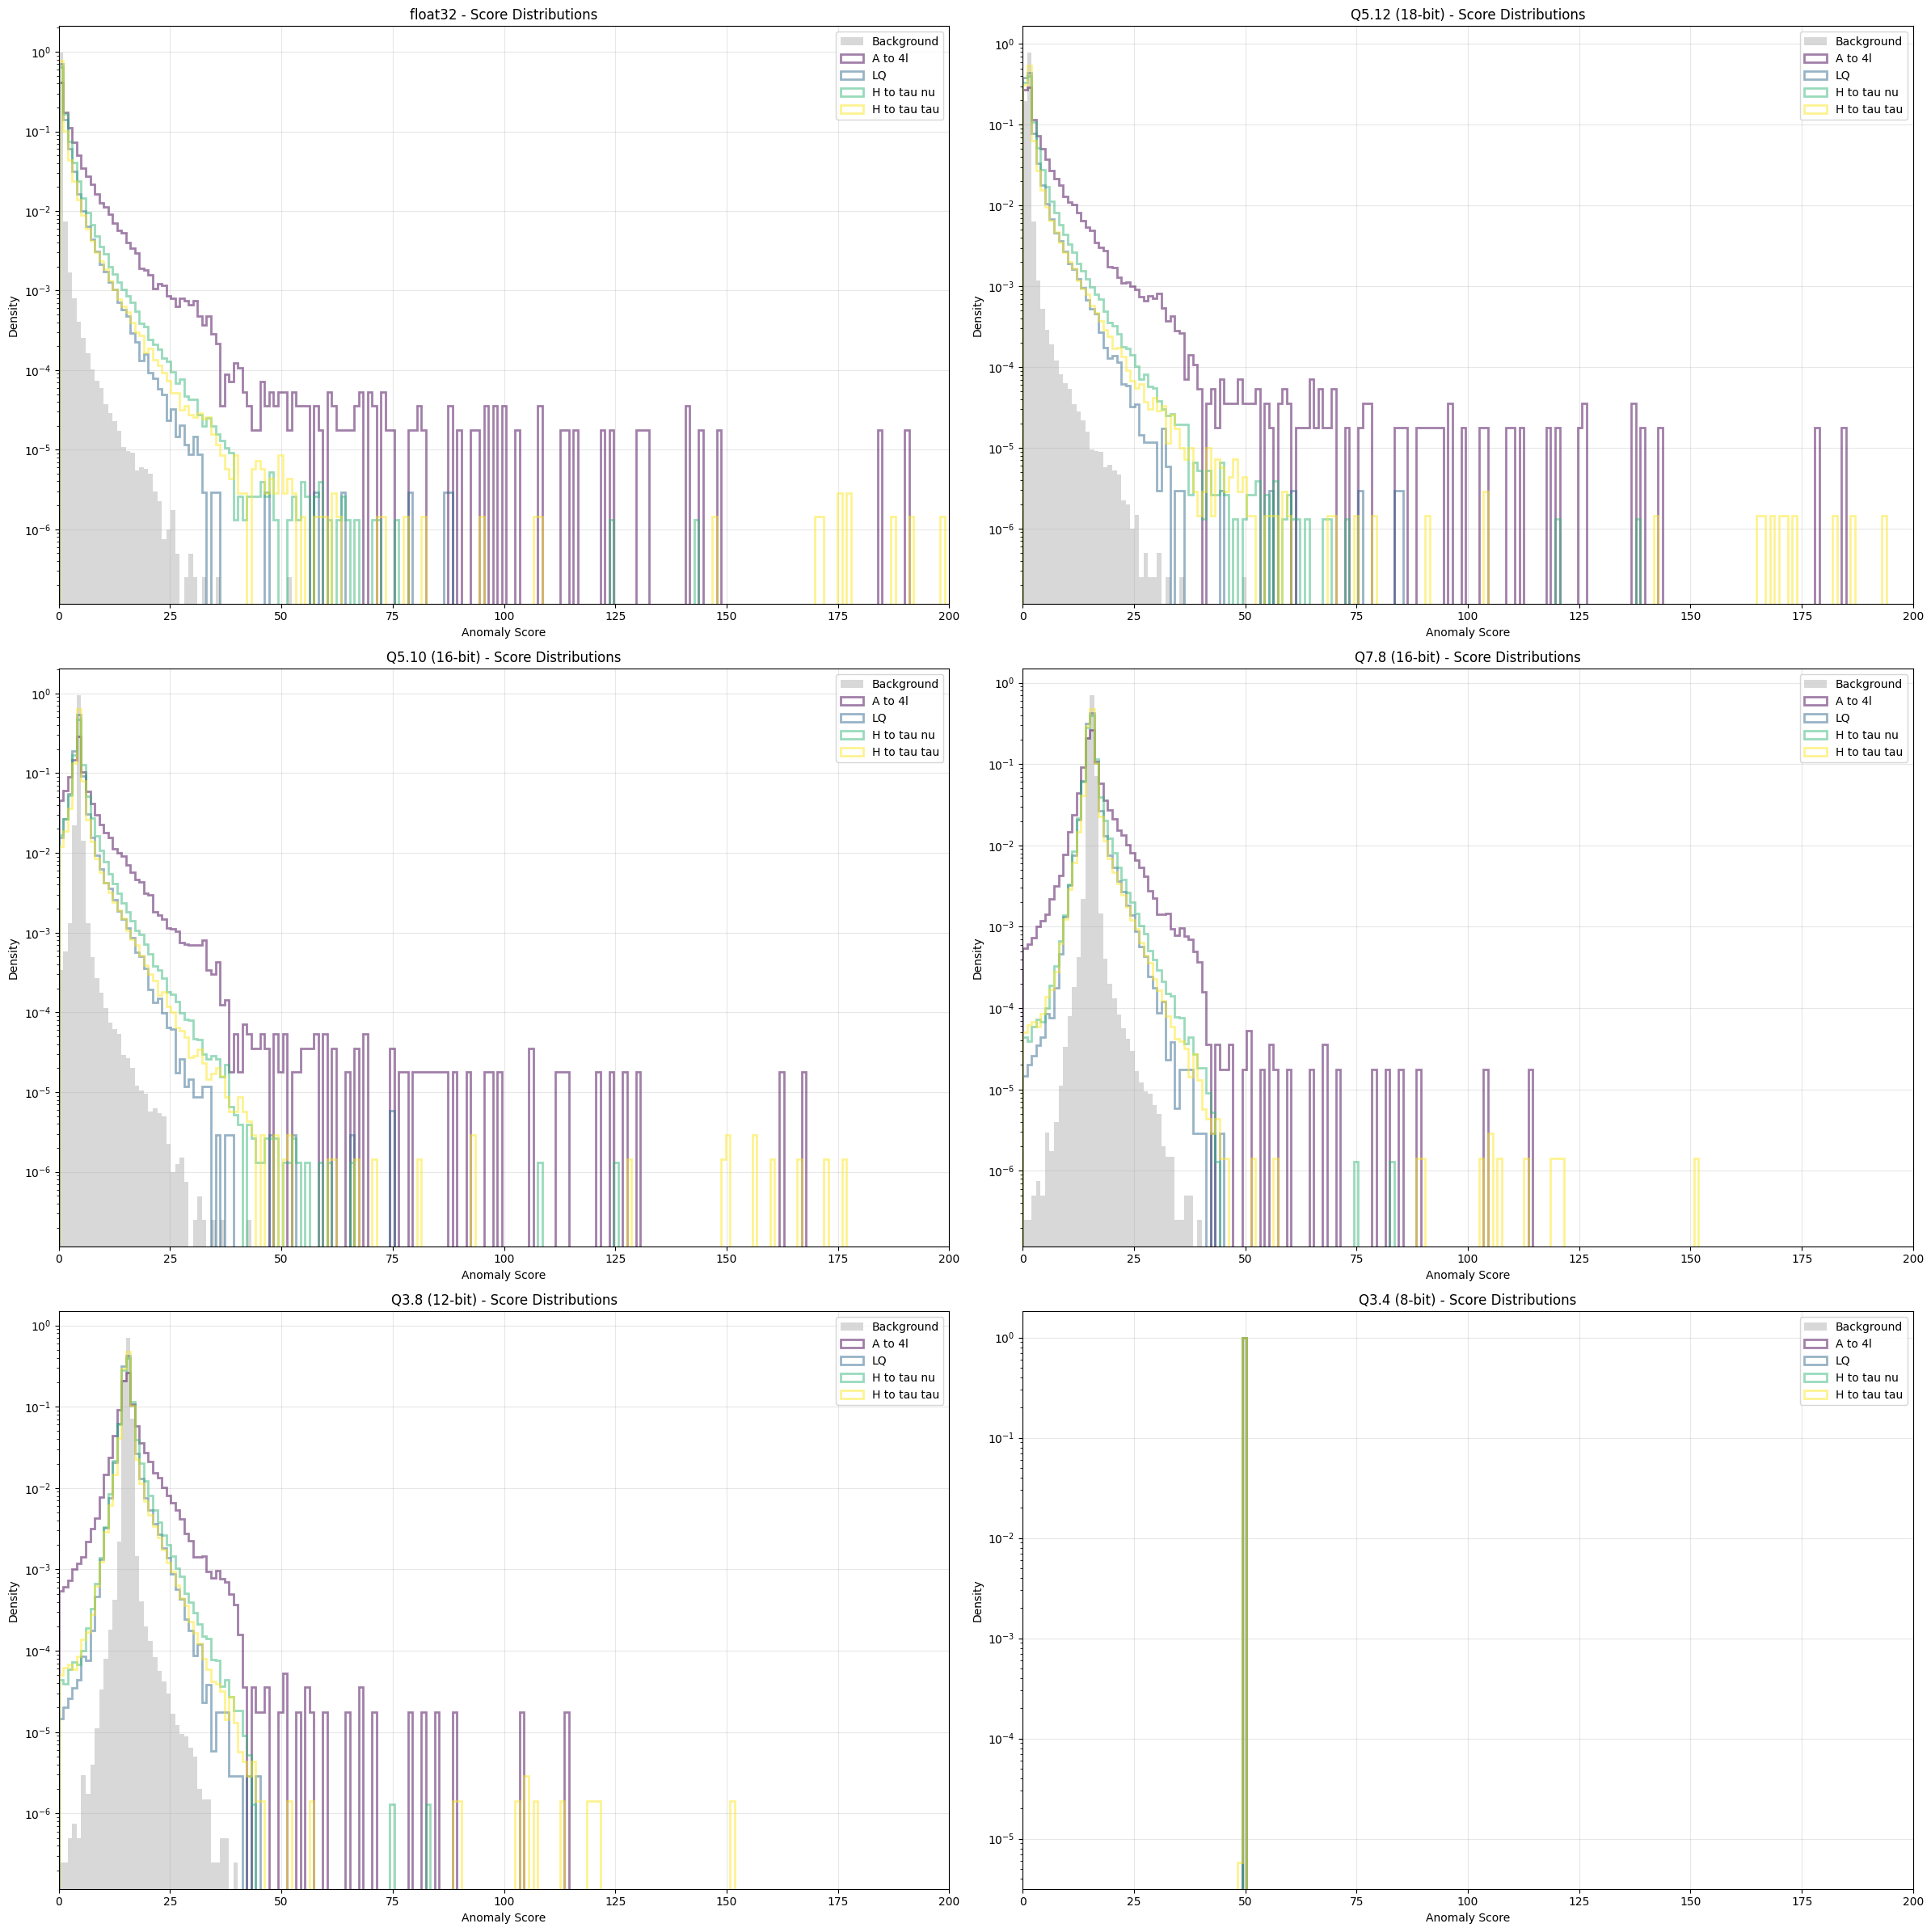

In [72]:
# Plot distributions for each precision
n_configs = len(all_results)
n_signals = len(signal_loaders)

import math
fig, axes = plt.subplots(math.ceil(n_configs/2), 2, figsize=(24, 4*n_configs))
if n_configs == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(all_results.items()):
    print(config_idx%2,int(config_idx/2))
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_scores = results['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals for each config
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])

    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{config_name} - Score Distributions')
    ax.legend(loc='best')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])


    # Find the median background score for this quantization
    optimal_target = np.median(bkg_scores)
    print(f"Optimal target for {config_name}: {optimal_target:.2f} (vs original 50.0)")

    # Recompute scores with adjusted target
    adjusted_scores = bkg_quant - optimal_target  # Center at 0

plt.tight_layout()
plt.savefig(output_dir+"/anomaly_score_distributions_byprecision.png")
plt.show()

## 10. Plot ROC Curves

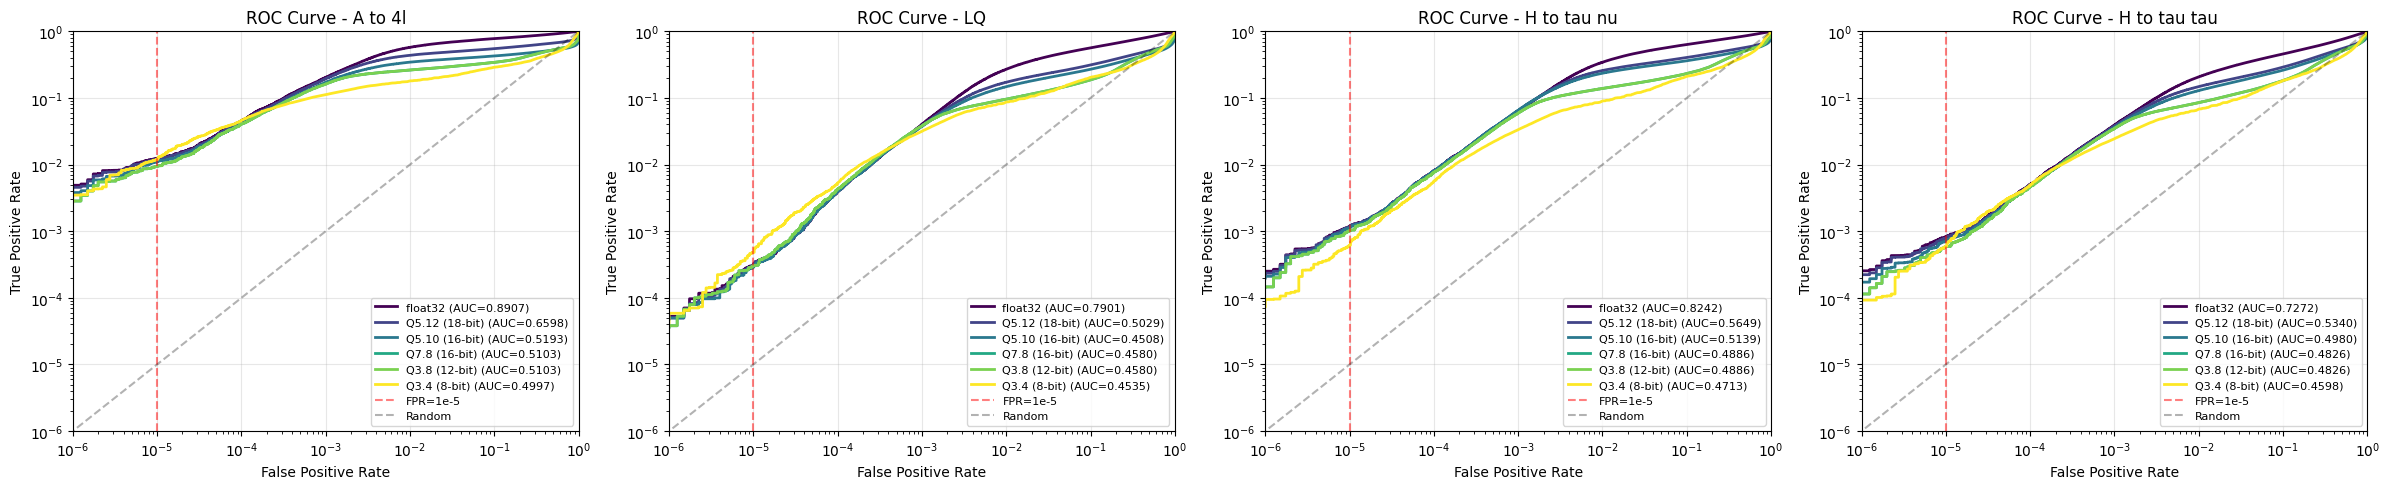

In [45]:
# Plot ROC curves for each signal
fig, axes = plt.subplots(1, n_signals, figsize=(6*n_signals, 5))
if n_signals == 1:
    axes = [axes]

for sig_idx, signal_name in enumerate(signal_loaders.keys()):
    ax = axes[sig_idx]
    
    # Plot ROC for each config
    for config_idx, (config_name, results) in enumerate(all_results.items()):
        bkg = results['background']
        sig = results['signals'][signal_name]
        
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, label=f'{config_name} (AUC={auc_val:.4f})',
                linewidth=2, color=colors[config_idx])
    
    # Add FPR = 1e-5 line
    ax.axvline(x=1e-5, color='red', linestyle='--', alpha=0.5, label='FPR=1e-5')
    
    # Diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {signal_name}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim([1e-6, 1])
    ax.set_ylim([1e-6, 1])

plt.tight_layout()
plt.savefig(output_dir+"/roc_curves.png")
plt.show()

## 11. Summary: AUC vs Bit-Width

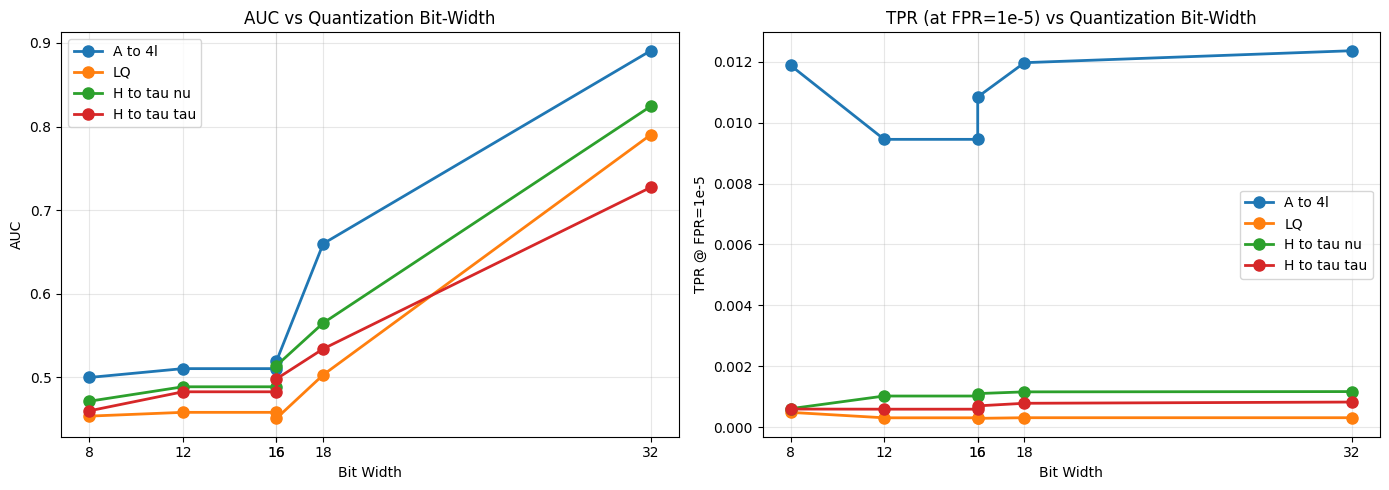

In [46]:
# Extract bit-widths for plotting
bit_widths = [32]  # float32
for n_word, n_frac, name in quantization_configs:
    bit_widths.append(n_word)

# Plot AUC vs bit-width for each signal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AUC plot
for signal_name in signal_loaders.keys():
    aucs = []
    for config_name in all_results.keys():
        bkg = all_results[config_name]['background']
        sig = all_results[config_name]['signals'][signal_name]
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        aucs.append(auc(fpr, tpr))
    
    ax1.plot(bit_widths, aucs, marker='o', linewidth=2, markersize=8, label=signal_name)

ax1.set_xlabel('Bit Width')
ax1.set_ylabel('AUC')
ax1.set_title('AUC vs Quantization Bit-Width')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xticks(bit_widths)

# TPR@1e-5 plot
for signal_name in signal_loaders.keys():
    tprs = []
    for config_name in all_results.keys():
        bkg = all_results[config_name]['background']
        sig = all_results[config_name]['signals'][signal_name]
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        tprs.append(get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5))
    
    ax2.plot(bit_widths, tprs, marker='o', linewidth=2, markersize=8, label=signal_name)

ax2.set_xlabel('Bit Width')
ax2.set_ylabel('TPR @ FPR=1e-5')
ax2.set_title('TPR (at FPR=1e-5) vs Quantization Bit-Width')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(bit_widths)

plt.tight_layout()
plt.savefig(output_dir+"/auc_vs_quantization.png")
plt.show()

## 12. Save Results

In [ ]:
# Save metrics table
df_metrics.to_csv(os.path.join(output_dir, 'quantization_metrics.csv'), index=False)
df_auc_deg.to_csv(os.path.join(output_dir, 'auc_degradation.csv'))
df_tpr_deg.to_csv(os.path.join(output_dir, 'tpr_degradation.csv'))

print(f"✅ Results saved to {output_dir}")

✅ Results saved to ../output/Huber_AE_Results_bd8_3/quantization_results
